<a href="https://colab.research.google.com/github/nishanthreddy16/Ad-Revenue-Optimization-Model/blob/main/ad_revenue_optimization_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ad Revenue Optimization Model for Websites**

# **Import Libraries**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Dataset**

In [18]:
df = pd.read_csv("ad_revenue_dataset.csv", on_bad_lines='skip')

# **Dataset Information**

In [19]:
df.head(5)

,page_views,bounce_rate,session_duration,ad_click_rate,ad_revenue
0,16795,28.885216,400.370999,7.691492,684.814628
1,1860,79.864429,57.393587,0.945516,44.142121
2,39158,36.006861,571.013067,3.052389,2002.223735
3,45732,78.596897,535.407821,0.710755,1918.616690
4,12284,44.662221,178.709365,5.232569,353.656406


In [20]:
df.shape

(200, 5)

In [21]:
df.columns

Index(['page_views', 'bounce_rate', 'session_duration', 'ad_click_rate',
       'ad_revenue'],
      dtype='object')

In [22]:
df.dtypes

,0
page_views,int64
bounce_rate,float64
session_duration,float64
ad_click_rate,float64
ad_revenue,float64


In [23]:
df.describe()

,page_views,bounce_rate,session_duration,ad_click_rate,ad_revenue
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,24060.420000,49.847933,321.450462,5.439321,1168.958275
std,14686.119776,17.449366,163.000438,2.665657,745.642857
min,1161.000000,20.311092,37.793020,0.524653,-322.355733
25%,11151.000000,35.341767,178.489766,3.552802,522.065233
50%,23532.500000,48.207354,326.883443,5.615961,1127.424486
75%,37206.250000,64.245365,452.816487,7.623458,1868.021700
max,49984.000000,79.864429,597.680808,9.973928,2614.833558


# **Data Cleaning**

In [24]:
df.isnull().sum()

,0
page_views,0
bounce_rate,0
session_duration,0
ad_click_rate,0
ad_revenue,0


In [25]:
df.fillna(0, inplace=True)

In [26]:
df.duplicated().any()

np.False_

In [27]:
df.drop_duplicates(inplace=True)


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   page_views        200 non-null    int64  
 1   bounce_rate       200 non-null    float64
 2   session_duration  200 non-null    float64
 3   ad_click_rate     200 non-null    float64
 4   ad_revenue        200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


# **Data Visualization**

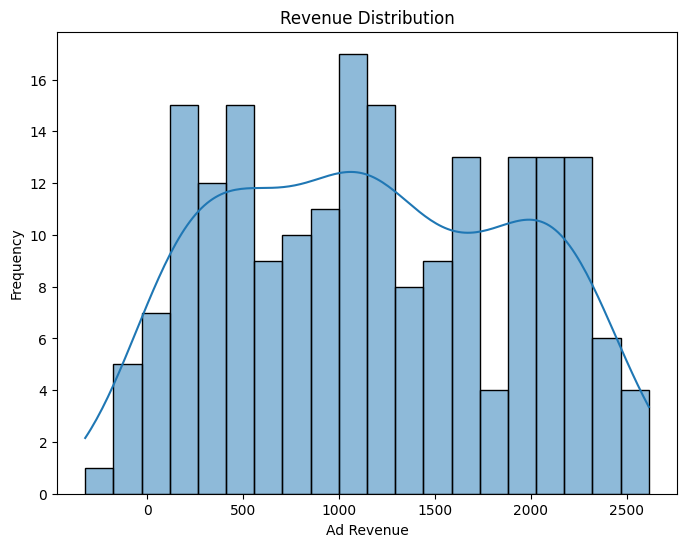

In [29]:
plt.figure(figsize=(8,6))

sns.histplot(df['ad_revenue'], bins=20, kde=True)

plt.title("Revenue Distribution")

plt.xlabel("Ad Revenue")

plt.ylabel("Frequency")

plt.show()

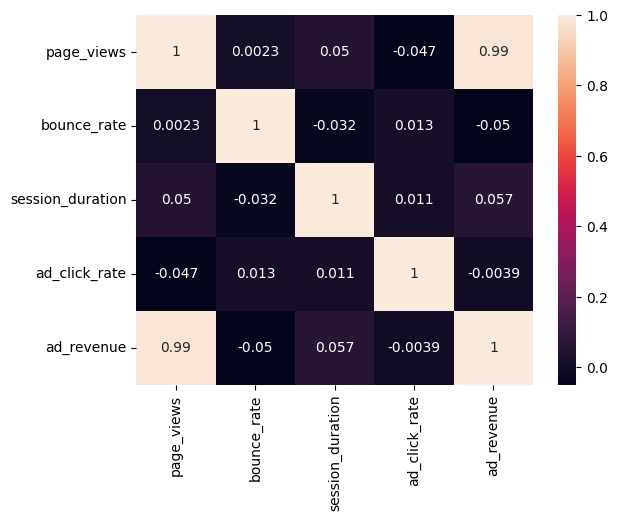

In [30]:
sns.heatmap(df.corr(), annot=True)
plt.show()

# **Feature Engineering**

In [31]:
df['engagement_score'] = df['page_views'] * df['session_duration']

In [32]:
df['effective_views'] = df['page_views'] * (1 - df['bounce_rate'] / 100)

In [33]:
df['avg_session_per_view'] = df['session_duration'] / df['page_views']

In [34]:
df.replace([np.inf, -np.inf], 0, inplace=True)

In [35]:
df.head()

,page_views,bounce_rate,session_duration,ad_click_rate,ad_revenue,engagement_score,effective_views,avg_session_per_view
0,16795,28.885216,400.370999,7.691492,684.814628,6.724231e+06,11943.728007,0.023839
1,1860,79.864429,57.393587,0.945516,44.142121,1.067521e+05,374.521619,0.030857
2,39158,36.006861,571.013067,3.052389,2002.223735,2.235973e+07,25058.433426,0.014582
3,45732,78.596897,535.407821,0.710755,1918.616690,2.448527e+07,9788.066904,0.011708
4,12284,44.662221,178.709365,5.232569,353.656406,2.195266e+06,6797.692797,0.014548


# **Updated Dataset Information**

In [36]:
df.shape

(200, 8)

In [37]:
df.columns

Index(['page_views', 'bounce_rate', 'session_duration', 'ad_click_rate',
       'ad_revenue', 'engagement_score', 'effective_views',
       'avg_session_per_view'],
      dtype='object')

In [38]:
df.dtypes

,0
page_views,int64
bounce_rate,float64
session_duration,float64
ad_click_rate,float64
ad_revenue,float64
engagement_score,float64
effective_views,float64
avg_session_per_view,float64


In [39]:
df.describe()


,page_views,bounce_rate,session_duration,ad_click_rate,ad_revenue,engagement_score,effective_views,avg_session_per_view
count,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02,200.000000,200.000000
mean,24060.420000,49.847933,321.450462,5.439321,1168.958275,7.852602e+06,12061.028496,0.029865
std,14686.119776,17.449366,163.000438,2.665657,745.642857,6.493583e+06,8623.391650,0.048521
min,1161.000000,20.311092,37.793020,0.524653,-322.355733,9.551705e+04,323.243831,0.001112
25%,11151.000000,35.341767,178.489766,3.552802,522.065233,2.451034e+06,5293.768185,0.007409
50%,23532.500000,48.207354,326.883443,5.615961,1127.424486,6.019740e+06,10493.359445,0.012997
75%,37206.250000,64.245365,452.816487,7.623458,1868.021700,1.229989e+07,18542.884987,0.028322
max,49984.000000,79.864429,597.680808,9.973928,2614.833558,2.546127e+07,34629.224888,0.321619


# **Model Development**

In [40]:
X = df.drop('ad_revenue', axis=1)
y = df['ad_revenue']

In [41]:
print(X.shape)
print(y.shape)

(200, 7)
(200,)


# **Train Test Split**

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# **Linear Regression**

In [43]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# **Revenue Prediction**

In [44]:
y_pred = model.predict(X_test)

# **Actual vs Predicted Graph**

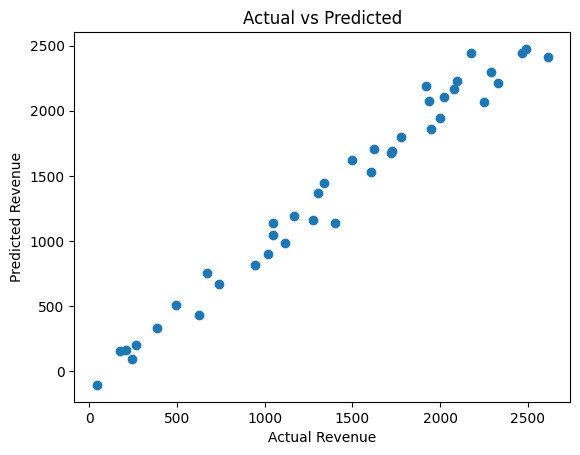

In [45]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title("Actual vs Predicted")

plt.show()

In [46]:
y_pred[:5]

array([2163.8798622 , 1673.76864067, 1796.54187943, 1691.4065558 ,
       2211.11506824])

In [47]:
y_test.head()

,ad_revenue
47,2079.350350
186,1720.391642
189,1777.164296
185,1729.049605
45,2331.109893


# **Accuracy Check**

In [48]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9725106991509326

# **Model Evaluation**

In [49]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)


rmse = np.sqrt(mse)
print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)

MAE = 98.89127575904958
MSE = 14666.232129823233
RMSE = 121.10422011566415


# **Clustering**

In [50]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)

In [51]:
df['cluster'] = kmeans.fit_predict(X)

In [52]:
df.head()

,page_views,bounce_rate,session_duration,ad_click_rate,ad_revenue,engagement_score,effective_views,avg_session_per_view,cluster
0,16795,28.885216,400.370999,7.691492,684.814628,6.724231e+06,11943.728007,0.023839,1
1,1860,79.864429,57.393587,0.945516,44.142121,1.067521e+05,374.521619,0.030857,1
2,39158,36.006861,571.013067,3.052389,2002.223735,2.235973e+07,25058.433426,0.014582,0
3,45732,78.596897,535.407821,0.710755,1918.616690,2.448527e+07,9788.066904,0.011708,0
4,12284,44.662221,178.709365,5.232569,353.656406,2.195266e+06,6797.692797,0.014548,1


# **Cluster Count**

In [53]:
df['cluster'].value_counts()

,count
cluster,
1,112
2,58
0,30


In [54]:
df.groupby('cluster').mean()

,page_views,bounce_rate,session_duration,ad_click_rate,ad_revenue,engagement_score,effective_views,avg_session_per_view
cluster,,,,,,,,
0,41227.766667,48.282426,484.926114,4.809369,2046.805332,1.962596e+07,21165.573213,0.012332
1,15553.017857,48.399633,247.764745,5.460569,741.061831,3.040375e+06,8211.077206,0.042608
2,31608.844828,53.454395,379.183749,5.724126,1541.182240,1.105551e+07,14786.169925,0.014326


# **Visualization & Insight Generation**

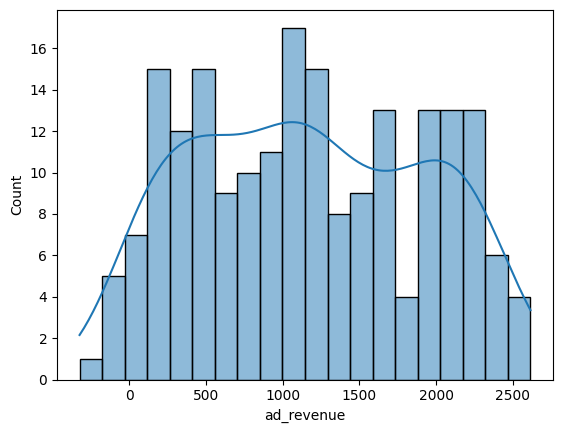

In [55]:
sns.histplot(
      df['ad_revenue'],
      bins=20,
      kde=True
)

plt.show()

# **Page Views vs Revenue**

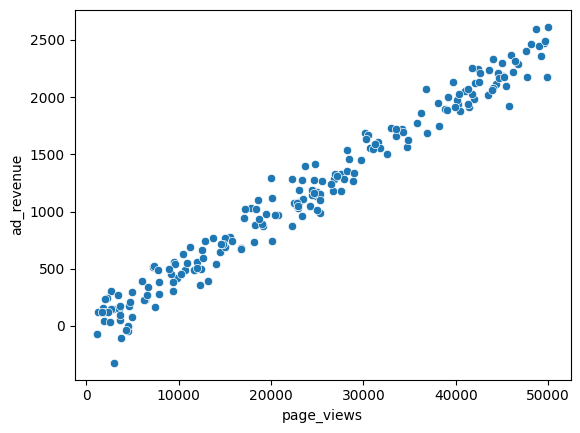

In [56]:
sns.scatterplot(
      x='page_views',
      y='ad_revenue',
      data=df
)

plt.show()

# **Session Duration vs Revenue**

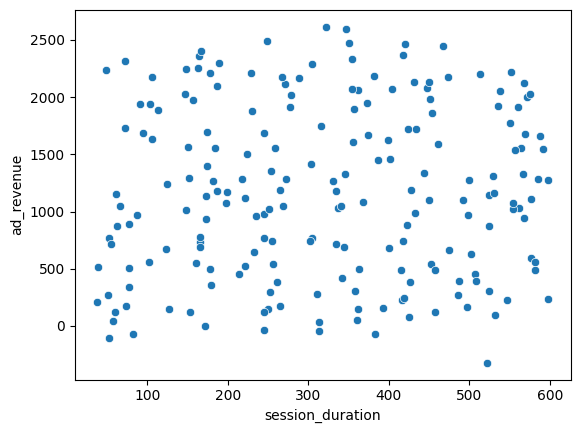

In [57]:
sns.scatterplot(
      x='session_duration',
      y='ad_revenue',
      data=df
)

plt.show()

# **Bounce Rate vs Revenue**

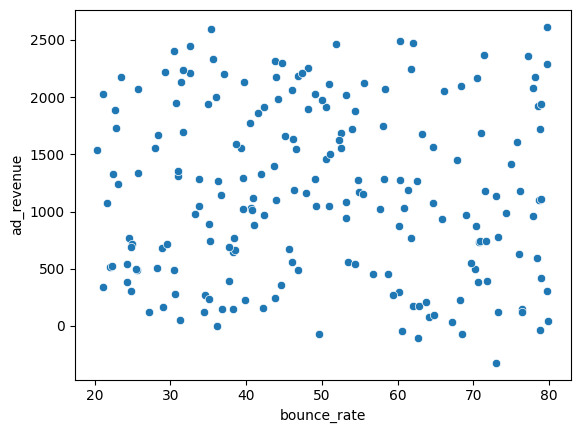

In [58]:
sns.scatterplot(
      x='bounce_rate',
      y='ad_revenue',
      data=df
)

plt.show()

# **Business Insights**

In [59]:
print(
  """
  1. Higher page views increase revenue.

  2. Longer session duration improves engagement.

  3. Higher ad click rate improves earnings.

  4. Lower bounce rate improves website performance.

  5. High engagement leads to higher revenue.
  """
)


  1. Higher page views increase revenue.

  2. Longer session duration improves engagement.

  3. Higher ad click rate improves earnings.

  4. Lower bounce rate improves website performance.

  5. High engagement leads to higher revenue.
  
